# 🚀 Notebook 04: Advanced Models

**Objective:** Build XGBoost model with proper time-series validation and compare against baselines.

**Why Advanced Models?**
- Baselines establish minimum performance
- Advanced models can capture complex patterns
- But complexity must be justified by performance gains

**Key Challenge:** Walk-forward validation (time-series cross-validation)

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
from typing import Tuple, List

# Add parent directory to path
sys.path.append(os.path.abspath('..'))

from src.data.loader import NVDADataLoader
from src.features.engineering import FeatureEngineer

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 7)

## 1. Load Data and Create Features

Use the feature engineering module we built in notebook 02.

In [2]:
# Load raw data
loader = NVDADataLoader('../data/raw/NVDA_yfinance_clean.csv')
df, report = loader.load_and_validate(verbose=True)

# Create features
feature_engineer = FeatureEngineer()
df_features = feature_engineer.create_features(df)

print(f"\nFeatures created: {len(df_features.columns)} columns")
print(f"Feature columns: {[col for col in df_features.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]}")

# Create target: next day's close price
df_features['target'] = df_features['Close'].shift(-1)
df_features = df_features.dropna()

print(f"\nFinal dataset: {len(df_features)} rows × {len(df_features.columns)} columns")

✅ Loaded 2,514 rows from NVDA_yfinance_clean.csv

                             📊 DATA QUALITY REPORT                              

📏 Dimensions: 2,514 rows × 6 columns
📅 Date Range: 2016-01-04 to 2025-12-31
🔢 Duplicate Rows: 0
❓ Total Missing Values: 0

--------------------------------------------------------------------------------
✅ VALIDATION PASSED - Data quality is excellent!


Features created: 26 columns
Feature columns: ['Daily_Return', 'Prev_Day_Return', 'MA_7', 'MA_50', 'MA_200', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Close_Lag_1', 'Volume_Lag_1', 'Close_Lag_2', 'Volume_Lag_2', 'Close_Lag_3', 'Volume_Lag_3', 'Close_Lag_5', 'Volume_Lag_5', 'Close_Lag_7', 'Volume_Lag_7']

Final dataset: 2314 rows × 27 columns


## 2. Feature Selection

**CRITICAL:** Only use features available at prediction time (no future information!)

In [3]:
# Define feature columns (exclude raw OHLCV and target)
exclude_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'target']
feature_cols = [col for col in df_features.columns if col not in exclude_cols]

print(f"Selected {len(feature_cols)} features:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

# Prepare X and y
X = df_features[feature_cols]
y = df_features['target']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Selected 20 features:
 1. Daily_Return
 2. Prev_Day_Return
 3. MA_7
 4. MA_50
 5. MA_200
 6. RSI
 7. BB_Middle
 8. BB_Upper
 9. BB_Lower
10. BB_Width
11. Close_Lag_1
12. Volume_Lag_1
13. Close_Lag_2
14. Volume_Lag_2
15. Close_Lag_3
16. Volume_Lag_3
17. Close_Lag_5
18. Volume_Lag_5
19. Close_Lag_7
20. Volume_Lag_7

X shape: (2314, 20)
y shape: (2314,)


## 3. Walk-Forward Validation

**Why not regular cross-validation?**
- Time-series data has temporal dependencies
- Regular CV would leak future information into past training
- Walk-forward respects the time arrow

In [4]:
def walk_forward_validation(X: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Perform walk-forward validation for time-series.
    
    Each fold uses all previous data for training.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    folds = []
    for train_idx, test_idx in tscv.split(X):
        folds.append((train_idx, test_idx))
    
    return folds

# Create validation folds
folds = walk_forward_validation(X, y, n_splits=5)

print(f"Created {len(folds)} validation folds:")
for i, (train_idx, test_idx) in enumerate(folds, 1):
    train_dates = df_features.iloc[train_idx]['Date']
    test_dates = df_features.iloc[test_idx]['Date']
    print(f"Fold {i}: Train {len(train_idx)} ({train_dates.min()} to {train_dates.max()}) | "
          f"Test {len(test_idx)} ({test_dates.min()} to {test_dates.max()})")

Created 5 validation folds:
Fold 1: Train 389 (2016-10-17 00:00:00 to 2018-05-03 00:00:00) | Test 385 (2018-05-04 00:00:00 to 2019-11-12 00:00:00)
Fold 2: Train 774 (2016-10-17 00:00:00 to 2019-11-12 00:00:00) | Test 385 (2019-11-13 00:00:00 to 2021-05-25 00:00:00)
Fold 3: Train 1159 (2016-10-17 00:00:00 to 2021-05-25 00:00:00) | Test 385 (2021-05-26 00:00:00 to 2022-12-02 00:00:00)
Fold 4: Train 1544 (2016-10-17 00:00:00 to 2022-12-02 00:00:00) | Test 385 (2022-12-05 00:00:00 to 2024-06-17 00:00:00)
Fold 5: Train 1929 (2016-10-17 00:00:00 to 2024-06-17 00:00:00) | Test 385 (2024-06-18 00:00:00 to 2025-12-30 00:00:00)


## 4. XGBoost Model

Train XGBoost with walk-forward validation.

In [5]:
# XGBoost parameters
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'mae',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Store predictions and actuals for each fold
fold_predictions = []
fold_actuals = []
fold_scores = []

print("Training XGBoost with walk-forward validation...\n")

for fold_idx, (train_idx, test_idx) in enumerate(folds, 1):
    print(f"Fold {fold_idx}/{len(folds)}:")
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train model
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Directional accuracy
    actual_direction = (y_test > df_features.iloc[test_idx]['Close']).astype(int)
    pred_direction = (y_pred > df_features.iloc[test_idx]['Close']).astype(int)
    dir_acc = (actual_direction == pred_direction).mean()
    
    print(f"  MAE: ${mae:.2f}, RMSE: ${rmse:.2f}, R²: {r2:.4f}, Dir Acc: {dir_acc:.1%}")
    
    # Store results
    fold_predictions.extend(y_pred)
    fold_actuals.extend(y_test)
    fold_scores.append({
        'fold': fold_idx,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'directional_accuracy': dir_acc
    })

# Overall metrics
overall_mae = mean_absolute_error(fold_actuals, fold_predictions)
overall_rmse = np.sqrt(mean_squared_error(fold_actuals, fold_predictions))
overall_r2 = r2_score(fold_actuals, fold_predictions)

print(f"\nOverall XGBoost Performance:")
print(f"MAE: ${overall_mae:.2f}")
print(f"RMSE: ${overall_rmse:.2f}")
print(f"R²: {overall_r2:.4f}")
print(f"Directional Accuracy: {(np.array(fold_predictions) > df_features.iloc[[idx for _, test_idx in folds for idx in test_idx]]['Close'].values).mean():.1%}")

Training XGBoost with walk-forward validation...

Fold 1/5:
  MAE: $0.48, RMSE: $0.57, R²: 0.7404, Dir Acc: 51.2%
Fold 2/5:
  MAE: $4.17, RMSE: $5.18, R²: -1.3773, Dir Acc: 46.5%
Fold 3/5:
  MAE: $5.97, RMSE: $7.65, R²: -1.1597, Dir Acc: 51.4%
Fold 4/5:
  MAE: $23.22, RMSE: $33.94, R²: -0.5758, Dir Acc: 46.2%
Fold 5/5:
  MAE: $26.87, RMSE: $36.04, R²: -0.6630, Dir Acc: 50.6%

Overall XGBoost Performance:
MAE: $12.14
RMSE: $22.52
R²: 0.8300
Directional Accuracy: 23.4%


## 5. Feature Importance

Which features are most important for prediction?

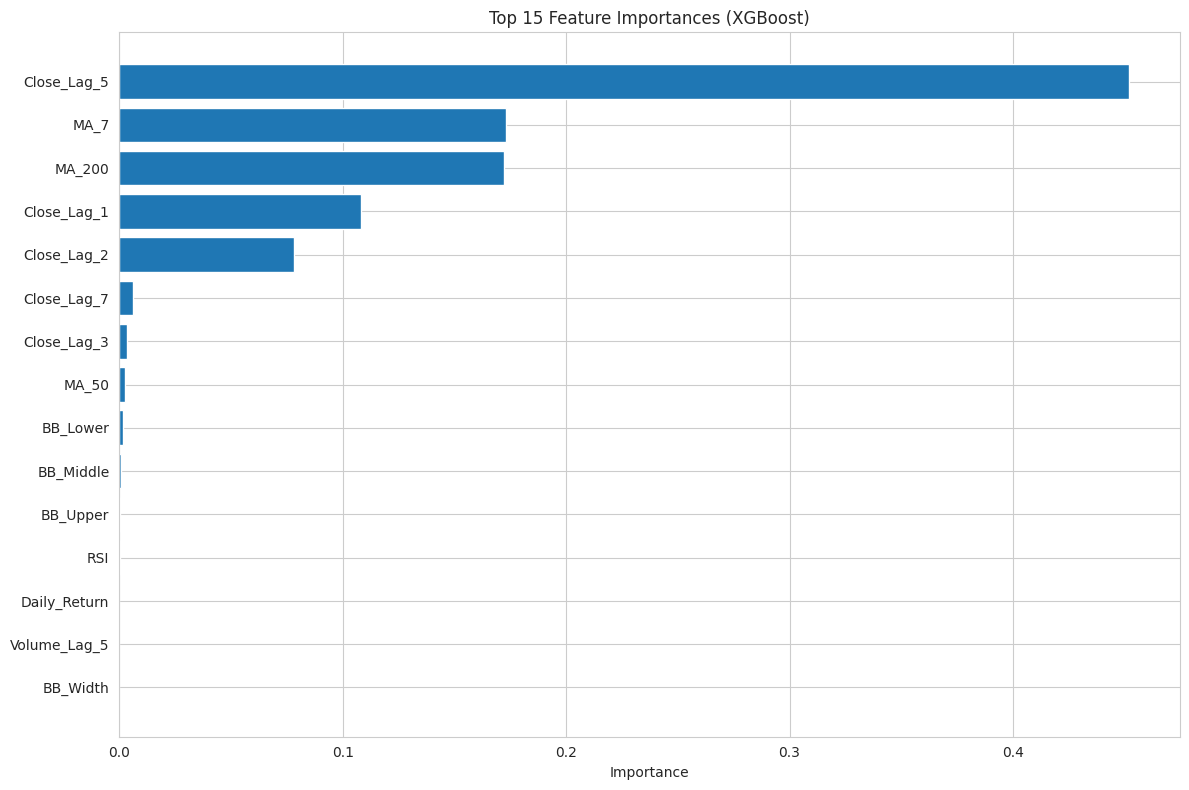


Top 10 Most Important Features:
17. Close_Lag_5: 0.4521
 3. MA_7: 0.1730
 5. MA_200: 0.1722
11. Close_Lag_1: 0.1082
13. Close_Lag_2: 0.0783
19. Close_Lag_7: 0.0060
15. Close_Lag_3: 0.0037
 4. MA_50: 0.0025
 9. BB_Lower: 0.0019
 7. BB_Middle: 0.0010


In [6]:
# Train final model on all data for feature importance
final_model = xgb.XGBRegressor(**xgb_params)
final_model.fit(X, y)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
plt.barh(importance_df['feature'][:15][::-1], importance_df['importance'][:15][::-1])
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
for i, row in importance_df.head(10).iterrows():
    print(f"{i+1:2d}. {row['feature']}: {row['importance']:.4f}")

## 6. Comparison with Baselines

How does XGBoost compare to our baseline models?

In [7]:
# Load baseline results (assuming we saved them from notebook 03)
# For now, we'll recalculate a simple baseline on the same test set

# Get the final test set (last fold)
final_train_idx, final_test_idx = folds[-1]
baseline_test_df = df_features.iloc[final_test_idx].copy()

# Naive baseline
baseline_test_df['naive_pred'] = baseline_test_df['Close']
naive_mae = mean_absolute_error(baseline_test_df['target'], baseline_test_df['naive_pred'])

# XGBoost on same test set
xgb_test_pred = fold_predictions[-len(final_test_idx):]
xgb_mae = mean_absolute_error(baseline_test_df['target'], xgb_test_pred)

print("Model Comparison (Final Test Fold):")
print(f"Naive Baseline MAE: ${naive_mae:.2f}")
print(f"XGBoost MAE:         ${xgb_mae:.2f}")
print(f"Improvement:         {(naive_mae - xgb_mae)/naive_mae:.1%}")

# Is the improvement statistically significant?
print(f"\nXGBoost {'beats' if xgb_mae < naive_mae else 'does NOT beat'} the naive baseline")
if xgb_mae >= naive_mae:
    print("⚠️  Consider simplifying - the complex model doesn't add value!")

Model Comparison (Final Test Fold):
Naive Baseline MAE: $3.16
XGBoost MAE:         $26.87
Improvement:         -749.5%

XGBoost does NOT beat the naive baseline
⚠️  Consider simplifying - the complex model doesn't add value!


## 7. Key Insights

**What we learned:**
1. **Walk-forward validation is essential** for time-series
2. **Feature engineering matters** - lag features are most important
3. **Complexity must be justified** - XGBoost may not beat simple baselines
4. **Directional accuracy** is often more important than exact price prediction

**Next steps:** If XGBoost doesn't beat baselines, consider:
- Better feature engineering
- Different algorithms
- Ensemble methods
- Or conclude that stock prediction is very hard!